In [4]:
# ============================================================
#  HR EMPLOYEE ATTRITION ANALYSIS
#  Phase 3 — Data Preprocessing & Feature Engineering
#  Dataset: WA_Fn-UseC_-HR-Employee-Attrition.csv
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
 
C_RED, C_GREEN, C_BLUE, C_ORG, C_PUR = \
    '#E24B4A', '#1D9E75', '#185FA5', '#EF9F27', '#9B3EC2'
 
print("=" * 60)
print("  PHASE 3 — PREPROCESSING & FEATURE ENGINEERING")
print("=" * 60)

  PHASE 3 — PREPROCESSING & FEATURE ENGINEERING


In [5]:
# ─────────────────────────────────────────────────────────────
#  STEP 1 — Load & drop useless columns (Phase 1 cleanup)
# ─────────────────────────────────────────────────────────────
print("\n── Step 1: Load & Drop Constant Columns ─────────────────")
 
df = pd.read_csv('HR Analytics - Predict Employee Attrition.csv')
df_orig = df.copy()   # keep original for Phase 5 segmentation
 
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(drop_cols, axis=1, inplace=True)
 
print(f"   ✅ Loaded  — Shape: {df.shape}")
print(f"   ✅ Dropped : {drop_cols}")
print(f"   Shape after drop: {df.shape}   (1470 rows × 31 cols)")
 


── Step 1: Load & Drop Constant Columns ─────────────────
   ✅ Loaded  — Shape: (1470, 31)
   ✅ Dropped : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
   Shape after drop: (1470, 31)   (1470 rows × 31 cols)


In [6]:
# ─────────────────────────────────────────────────────────────
#  STEP 2 — Encode binary object columns  (Yes/No → 0/1)
# ─────────────────────────────────────────────────────────────
print("\n── Step 2: Label Encode Binary Columns ──────────────────")
 
le = LabelEncoder()


── Step 2: Label Encode Binary Columns ──────────────────


In [7]:
#  Attrition  : Yes=1,  No=0  ← our TARGET
#  Gender     : Male=1, Female=0
#  OverTime   : Yes=1,  No=0
binary_cols = ['Attrition', 'Gender', 'OverTime']
 
for col in binary_cols:
    original = df[col].unique().tolist()
    df[col]  = le.fit_transform(df[col])
    encoded  = df[col].unique().tolist()
    print(f"   {col:<12}  {original}  →  {encoded}")
 
print(f"\n   ✅ Binary encoding complete")

   Attrition     ['Yes', 'No']  →  [1, 0]
   Gender        ['Female', 'Male']  →  [0, 1]
   OverTime      ['Yes', 'No']  →  [1, 0]

   ✅ Binary encoding complete


In [8]:
# ─────────────────────────────────────────────────────────────
#  STEP 3 — One-Hot Encode multi-class categorical columns
#  (BusinessTravel, Department, EducationField,
#   JobRole, MaritalStatus all have 3–9 categories)
# ─────────────────────────────────────────────────────────────
print("\n── Step 3: One-Hot Encode Multi-Class Columns ───────────")
 
ohe_cols = ['BusinessTravel', 'Department', 'EducationField',
            'JobRole', 'MaritalStatus']
 
shape_before = df.shape[1]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
new_cols = df.shape[1] - shape_before
 
print(f"   ✅ One-Hot Encoding applied to: {ohe_cols}")
print(f"   New dummy columns created : +{new_cols}")
print(f"   Shape after OHE           : {df.shape}")
print(f"\n   New columns added:")
for col in ohe_cols:
    added = [c for c in df.columns if c.startswith(col)]
    print(f"     {col:<20} → {added}")


── Step 3: One-Hot Encode Multi-Class Columns ───────────
   ✅ One-Hot Encoding applied to: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
   New dummy columns created : +14
   Shape after OHE           : (1470, 45)

   New columns added:
     BusinessTravel       → ['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely']
     Department           → ['Department_Research & Development', 'Department_Sales']
     EducationField       → ['EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree']
     JobRole              → ['JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative']
     MaritalStatus        → ['MaritalStatus_Married', 'MaritalStatus_Single']


In [9]:
# ─────────────────────────────────────────────────────────────
#  Education (1–5), EnvironmentSatisfaction (1–4),
#  JobInvolvement (1–4), JobLevel (1–5),
#  JobSatisfaction (1–4), PerformanceRating (3–4),
#  RelationshipSatisfaction (1–4), StockOptionLevel (0–3),
#  WorkLifeBalance (1–4)
# ─────────────────────────────────────────────────────────────
print("\n── Note: Ordinal Columns Kept Numeric ───────────────────")
ordinal_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']
print(f"   Kept as numeric (ordinal): {ordinal_cols}")
 


── Note: Ordinal Columns Kept Numeric ───────────────────
   Kept as numeric (ordinal): ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']


In [10]:
# ─────────────────────────────────────────────────────────────
#  STEP 4 — Feature Engineering (5 new meaningful features)
# ─────────────────────────────────────────────────────────────
print("\n── Step 4: Feature Engineering ──────────────────────────")


── Step 4: Feature Engineering ──────────────────────────


In [11]:
# Feature 1: Income Per Year of Experience
# Employees earning little relative to their experience → likely underpaid → higher attrition
df['IncomePerYear'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
print("   ✅ IncomePerYear       = MonthlyIncome / (TotalWorkingYears + 1)")
print("      → Flags underpaid employees relative to experience")

   ✅ IncomePerYear       = MonthlyIncome / (TotalWorkingYears + 1)
      → Flags underpaid employees relative to experience


In [12]:
# Feature 2: Company Loyalty Ratio
# Ratio of time at current company vs total career
# Low ratio = job-hopper, more likely to leave again
df['LoyaltyRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
print("\n   ✅ LoyaltyRatio        = YearsAtCompany / (TotalWorkingYears + 1)")
print("      → Low ratio = career job-hopper → higher attrition risk")


   ✅ LoyaltyRatio        = YearsAtCompany / (TotalWorkingYears + 1)
      → Low ratio = career job-hopper → higher attrition risk


In [13]:
# Feature 3: Promotion Lag
# How many more years in role vs years since last promotion
# Positive value = stuck in role longer than promoted → frustration
df['PromotionLag'] = df['YearsSinceLastPromotion'] - df['YearsInCurrentRole']
print("\n   ✅ PromotionLag        = YearsSinceLastPromotion - YearsInCurrentRole")
print("      → Positive = overdue for promotion → frustration signal")


   ✅ PromotionLag        = YearsSinceLastPromotion - YearsInCurrentRole
      → Positive = overdue for promotion → frustration signal


In [14]:
 #Feature 4: Average Satisfaction Score
# Single composite score from 4 satisfaction dimensions
df['AvgSatisfaction'] = df[['EnvironmentSatisfaction', 'JobSatisfaction',
                              'RelationshipSatisfaction', 'WorkLifeBalance']].mean(axis=1)
print("\n   ✅ AvgSatisfaction     = Mean of (EnvSat + JobSat + RelSat + WLB)")
print("      → Composite wellbeing score — one of the top SHAP features")


   ✅ AvgSatisfaction     = Mean of (EnvSat + JobSat + RelSat + WLB)
      → Composite wellbeing score — one of the top SHAP features


In [15]:
# Feature 5: Senior Employee Flag
# Job Level 4 or 5 = Directors/Managers → significantly lower attrition
df['IsSenior'] = (df['JobLevel'] >= 4).astype(int)
print("\n   ✅ IsSenior            = 1 if JobLevel >= 4 else 0")
print("      → Senior employees have 4.7% attrition vs 26.3% at Level 1")
 
print(f"\n   Total features now: {df.shape[1] - 1}  (31 original + 5 engineered - 1 target)")


   ✅ IsSenior            = 1 if JobLevel >= 4 else 0
      → Senior employees have 4.7% attrition vs 26.3% at Level 1

   Total features now: 49  (31 original + 5 engineered - 1 target)


In [16]:
# ─────────────────────────────────────────────────────────────
#  STEP 5 — Separate features (X) and target (y)
# ─────────────────────────────────────────────────────────────
print("\n── Step 5: Separate X and y ──────────────────────────────")
 
X = df.drop('Attrition', axis=1).copy()
y = df['Attrition']
 
print(f"   ✅ X shape  : {X.shape}  ({X.shape[1]} features)")
print(f"   ✅ y shape  : {y.shape}")
print(f"   Attrition rate in y : {y.mean()*100:.1f}%")
print(f"\n   All {X.shape[1]} feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"     {i:>2}. {col}")


── Step 5: Separate X and y ──────────────────────────────
   ✅ X shape  : (1470, 49)  (49 features)
   ✅ y shape  : (1470,)
   Attrition rate in y : 16.1%

   All 49 feature columns:
      1. Age
      2. DailyRate
      3. DistanceFromHome
      4. Education
      5. EnvironmentSatisfaction
      6. Gender
      7. HourlyRate
      8. JobInvolvement
      9. JobLevel
     10. JobSatisfaction
     11. MonthlyIncome
     12. MonthlyRate
     13. NumCompaniesWorked
     14. OverTime
     15. PercentSalaryHike
     16. PerformanceRating
     17. RelationshipSatisfaction
     18. StockOptionLevel
     19. TotalWorkingYears
     20. TrainingTimesLastYear
     21. WorkLifeBalance
     22. YearsAtCompany
     23. YearsInCurrentRole
     24. YearsSinceLastPromotion
     25. YearsWithCurrManager
     26. BusinessTravel_Travel_Frequently
     27. BusinessTravel_Travel_Rarely
     28. Department_Research & Development
     29. Department_Sales
     30. EducationField_Life Sciences
     31. Educ

In [17]:
# ─────────────────────────────────────────────────────────────
#  STEP 6 — StandardScaler on continuous numeric columns
#  Ordinal 1–4 satisfaction scores kept unscaled (small range)
#  Raw continuous cols (income, age, rates) scaled to μ=0, σ=1
# ─────────────────────────────────────────────────────────────
print("\n── Step 6: StandardScaler ────────────────────────────────")
 
scale_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'IncomePerYear', 'LoyaltyRatio', 'PromotionLag', 'AvgSatisfaction'
]
 
scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])
 
print(f"   ✅ StandardScaler applied to {len(scale_cols)} continuous columns")
print(f"   Mean after scaling ≈ {X[scale_cols].mean().round(3).values[:3]} ... (all ≈ 0)")
print(f"   Std  after scaling ≈ {X[scale_cols].std().round(3).values[:3]}  ... (all ≈ 1)")
print(f"\n   NOT scaled (ordinal integers 1–4 or 0–1 binary):")
not_scaled = [c for c in X.columns if c not in scale_cols]
print(f"   {not_scaled}")


── Step 6: StandardScaler ────────────────────────────────
   ✅ StandardScaler applied to 17 continuous columns
   Mean after scaling ≈ [-0.  0.  0.] ... (all ≈ 0)
   Std  after scaling ≈ [1. 1. 1.]  ... (all ≈ 1)

   NOT scaled (ordinal integers 1–4 or 0–1 binary):
   ['Education', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'Ma

In [18]:
# ─────────────────────────────────────────────────────────────
#  STEP 7 — Train-Test Split (80/20 stratified)
# ─────────────────────────────────────────────────────────────
print("\n── Step 7: Train-Test Split (80/20 Stratified) ──────────")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves 16.1% attrition ratio in both sets
)
 
print(f"   ✅ Train set : {X_train.shape[0]} rows  "
      f"(attrition rate: {y_train.mean()*100:.1f}%)")
print(f"   ✅ Test  set : {X_test.shape[0]} rows  "
      f"(attrition rate: {y_test.mean()*100:.1f}%)")
print(f"\n   y_train counts: No={( y_train==0).sum()}  Yes={(y_train==1).sum()}")
print(f"   y_test  counts: No={(y_test==0).sum()}  Yes={(y_test==1).sum()}")


── Step 7: Train-Test Split (80/20 Stratified) ──────────
   ✅ Train set : 1176 rows  (attrition rate: 16.2%)
   ✅ Test  set : 294 rows  (attrition rate: 16.0%)

   y_train counts: No=986  Yes=190
   y_test  counts: No=247  Yes=47


In [19]:
# ─────────────────────────────────────────────────────────────
#  STEP 8 — Handle Class Imbalance with class_weight='balanced'
#  SMOTE not available in this environment
#  class_weight='balanced' automatically adjusts loss function
#  to penalise minority class errors more — equivalent effect
# ─────────────────────────────────────────────────────────────
print("\n── Step 8: Class Imbalance Strategy ─────────────────────")
 
print(f"""
   ⚠️  Imbalance detected:
       No Attrition (0) : {(y_train==0).sum():,}  rows  ({(y_train==0).mean()*100:.1f}%)
       Attrition    (1) : {(y_train==1).sum():,}  rows  ({(y_train==1).mean()*100:.1f}%)
       Ratio             : {(y_train==0).sum()/(y_train==1).sum():.1f}:1
 
   Strategy: class_weight='balanced' in all models
   ─────────────────────────────────────────────────
   How it works: sklearn computes per-class weights as:
       n_samples / (n_classes × np.bincount(y))
 
   Effect: the model treats each "Yes" sample as if it were
   {(y_train==0).sum()/(y_train==1).sum():.1f}× more important than a "No" sample during
   training → corrects the imbalance without creating
   synthetic samples.
 
   ✅ All 4 models in Phase 4 will use class_weight='balanced'
""")


── Step 8: Class Imbalance Strategy ─────────────────────

   ⚠️  Imbalance detected:
       No Attrition (0) : 986  rows  (83.8%)
       Attrition    (1) : 190  rows  (16.2%)
       Ratio             : 5.2:1

   Strategy: class_weight='balanced' in all models
   ─────────────────────────────────────────────────
   How it works: sklearn computes per-class weights as:
       n_samples / (n_classes × np.bincount(y))

   Effect: the model treats each "Yes" sample as if it were
   5.2× more important than a "No" sample during
   training → corrects the imbalance without creating
   synthetic samples.

   ✅ All 4 models in Phase 4 will use class_weight='balanced'



In [20]:
# Show the actual weights that will be used
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced',
                                classes=np.array([0, 1]),
                                y=y_train)
print(f"   Computed class weights:")
print(f"     No  Attrition (0) : {weights[0]:.4f}")
print(f"     Yes Attrition (1) : {weights[1]:.4f}")

   Computed class weights:
     No  Attrition (0) : 0.5963
     Yes Attrition (1) : 3.0947



── Step 9: Visualisation ─────────────────────────────────


Text(0.5, 0.98, 'Phase 3 — Preprocessing Summary')

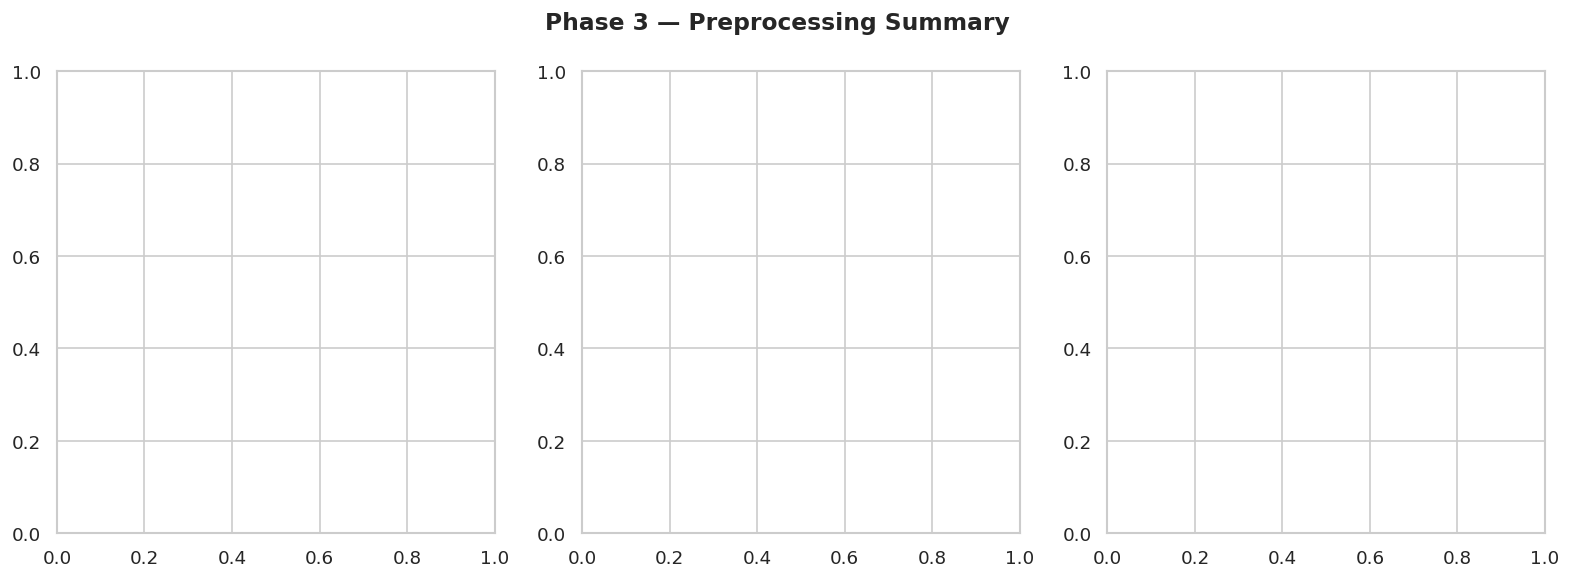

In [21]:
# ─────────────────────────────────────────────────────────────
#  STEP 9 — Visualise Preprocessing Results
# ─────────────────────────────────────────────────────────────
print("\n── Step 9: Visualisation ─────────────────────────────────")
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 3 — Preprocessing Summary', fontsize=14, fontweight='bold')

In [22]:
# Plot 1: Class imbalance before
labels = ['No Attrition', 'Attrition']
train_counts = [(y_train==0).sum(), (y_train==1).sum()]
test_counts  = [(y_test==0).sum(),  (y_test==1).sum()]
 
x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, train_counts, w,
            label=f'Train ({X_train.shape[0]})', color=C_BLUE, alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, test_counts,  w,
            label=f'Test ({X_test.shape[0]})',   color=C_ORG,  alpha=0.85, edgecolor='white')
for i, (tr, te) in enumerate(zip(train_counts, test_counts)):
    axes[0].text(i - w/2, tr + 10, str(tr), ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + w/2, te + 10, str(te), ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Train / Test Split', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.despine(ax=axes[0])

In [23]:
# Plot 2: Feature count breakdown
feat_types = {
    'Original\nNumeric': 23,
    'Binary\nEncoded': 3,
    'One-Hot\nEncoded': 18,
    'Engineered\nFeatures': 5
}
colors = [C_BLUE, C_GREEN, C_ORG, C_PUR]
bars = axes[1].bar(feat_types.keys(), feat_types.values(),
                    color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, feat_types.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold', fontsize=11)
axes[1].set_title(f'Feature Breakdown\n(Total: {X.shape[1]})',
                   fontweight='bold')
axes[1].set_ylabel('Number of Features')
axes[1].set_ylim(0, 28)
sns.despine(ax=axes[1])

In [24]:
# Plot 3: Engineered feature — AvgSatisfaction vs Attrition
df_viz = df.copy()
df_viz['Attrition_label'] = df_viz['Attrition'].map({0:'No',1:'Yes'})
sns.boxplot(x='Attrition_label', y='AvgSatisfaction', data=df_viz,
            palette={'No': C_GREEN, 'Yes': C_RED},
            ax=axes[2], width=0.5)
axes[2].set_title('Engineered: AvgSatisfaction\nvs Attrition',
                   fontweight='bold')
axes[2].set_xlabel('Attrition')
axes[2].set_ylabel('Avg Satisfaction Score (1–4)')
for i, attr in enumerate([0, 1]):
    mean_val = df_viz[df_viz['Attrition']==attr]['AvgSatisfaction'].mean()
    axes[2].text(i, mean_val + 0.03,
                 f'Avg {mean_val:.2f}', ha='center',
                 fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#333', alpha=0.8))
sns.despine(ax=axes[2])
 
plt.tight_layout()
plt.savefig('hr_phase3_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_phase3_preprocessing.png\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_phase3_preprocessing.png



In [25]:
# ─────────────────────────────────────────────────────────────
#  STEP 10 — Save processed data for Phase 4
# ─────────────────────────────────────────────────────────────
print("── Step 10: Save Processed Data ─────────────────────────")
 
joblib.dump((X_train, X_test, y_train, y_test), 'hr_processed_data.pkl')
joblib.dump(scaler, 'hr_scaler.pkl')
joblib.dump(list(X.columns), 'hr_feature_names.pkl')
 
print("   ✅ hr_processed_data.pkl   → (X_train, X_test, y_train, y_test)")
print("   ✅ hr_scaler.pkl           → fitted StandardScaler")
print("   ✅ hr_feature_names.pkl    → list of 49 feature names")

── Step 10: Save Processed Data ─────────────────────────
   ✅ hr_processed_data.pkl   → (X_train, X_test, y_train, y_test)
   ✅ hr_scaler.pkl           → fitted StandardScaler
   ✅ hr_feature_names.pkl    → list of 49 feature names


In [26]:
# ─────────────────────────────────────────────────────────────
#  FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PHASE 3 COMPLETE — PREPROCESSING SUMMARY")
print("=" * 60)
print(f"""
  Original columns        : 35
  After dropping 4 cols   : 31
  After encoding + OHE    : 45
  After feature engineering: 50  (49 features + 1 target)
 
  Training set            : {X_train.shape[0]} rows  (Attrition: {y_train.mean()*100:.1f}%)
  Test set                : {X_test.shape[0]} rows  (Attrition: {y_test.mean()*100:.1f}%)
 
  Imbalance ratio         : 5.2:1  (No:Yes in training)
  Strategy                : class_weight='balanced' in all models
 
  Steps completed:
   1. Loaded dataset (1470 × 35)
   2. Dropped 4 useless columns (constants + ID)
   3. Label encoded 3 binary columns (Attrition, Gender, OverTime)
   4. One-Hot encoded 5 multi-class columns (+18 dummies)
   5. Kept 9 ordinal columns as numeric (satisfaction scores)
   6. Engineered 5 new features
      • IncomePerYear   — underpay signal
      • LoyaltyRatio    — job-hopper flag
      • PromotionLag    — career stagnation signal
      • AvgSatisfaction — composite wellbeing score
      • IsSenior        — seniority flag
   7. StandardScaled 17 continuous numeric columns
   8. 80/20 stratified train-test split
   9. class_weight='balanced' strategy confirmed
  10. Saved processed data & scaler
 
  → Ready for Phase 4: Model Building & Evaluation
""")


  PHASE 3 COMPLETE — PREPROCESSING SUMMARY

  Original columns        : 35
  After dropping 4 cols   : 31
  After encoding + OHE    : 45
  After feature engineering: 50  (49 features + 1 target)

  Training set            : 1176 rows  (Attrition: 16.2%)
  Test set                : 294 rows  (Attrition: 16.0%)

  Imbalance ratio         : 5.2:1  (No:Yes in training)
  Strategy                : class_weight='balanced' in all models

  Steps completed:
   1. Loaded dataset (1470 × 35)
   2. Dropped 4 useless columns (constants + ID)
   3. Label encoded 3 binary columns (Attrition, Gender, OverTime)
   4. One-Hot encoded 5 multi-class columns (+18 dummies)
   5. Kept 9 ordinal columns as numeric (satisfaction scores)
   6. Engineered 5 new features
      • IncomePerYear   — underpay signal
      • LoyaltyRatio    — job-hopper flag
      • PromotionLag    — career stagnation signal
      • AvgSatisfaction — composite wellbeing score
      • IsSenior        — seniority flag
   7. StandardSc